In [2]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

In [3]:
design = pd.DataFrame({
    "Run": [1,2,3,4,5,6,7,8],
    "A":   [-1, 1,-1, 1,-1, 1,-1, 1],
    "B":   [-1,-1, 1, 1,-1,-1, 1, 1],
    "C":   [-1,-1,-1,-1, 1, 1, 1, 1]
})

design

,Run,A,B,C
0,1,-1,-1,-1
1,2,1,-1,-1
2,3,-1,1,-1
3,4,1,1,-1
4,5,-1,-1,1
5,6,1,-1,1
6,7,-1,1,1
7,8,1,1,1


In [4]:
distance = [354, 486 , 562 , 702 , 209 , 195 , 448 , 310] # Replace with your data

dfa = design.copy()
dfa["Distance"] = distance

dfa

,Run,A,B,C,Distance
0,1,-1,-1,-1,354
1,2,1,-1,-1,486
2,3,-1,1,-1,562
3,4,1,1,-1,702
4,5,-1,-1,1,209
5,6,1,-1,1,195
6,7,-1,1,1,448
7,8,1,1,1,310


In [9]:
model = ols("Distance ~ A*B*C", data=dfa)
results=model.fit()
print(results.summary2())

                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     nan      
Dependent Variable: Distance         AIC:                -430.9273
Date:               2026-04-14 09:22 BIC:                -430.2917
No. Observations:   8                Log-Likelihood:     223.46   
Df Model:           7                F-statistic:        nan      
Df Residuals:       0                Prob (F-statistic): nan      
R-squared:          1.000            Scale:              inf      
--------------------------------------------------------------------
              Coef.     Std.Err.      t      P>|t|   [0.025   0.975]
--------------------------------------------------------------------
Intercept    408.2500        inf    0.0000     nan      nan      nan
A             15.0000        inf    0.0000     nan      nan      nan
B             97.2500        inf    0.0000     nan      nan      nan
A:B          -14.5000        inf   -0.0000     nan      nan      nan

C:\Users\User\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid
C:\Users\User\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
C:\Users\User\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)


In [10]:
anova_lm(results)

C:\Users\User\anaconda3\Lib\site-packages\statsmodels\stats\anova.py:142: RuntimeWarning: divide by zero encountered in scalar divide
  (model.ssr / model.df_resid))


,df,sum_sq,mean_sq,F,PR(>F)
A,1.0,1.800000e+03,1800.0,0.0,NaN
B,1.0,7.566050e+04,75660.5,0.0,NaN
A:B,1.0,1.682000e+03,1682.0,0.0,NaN
C,1.0,1.109205e+05,110920.5,0.0,NaN
A:C,1.0,2.247200e+04,22472.0,0.0,NaN
B:C,1.0,6.125000e+02,612.5,0.0,NaN
A:B:C,1.0,2.178000e+03,2178.0,0.0,NaN
Residual,0.0,2.560706e-25,inf,NaN,NaN


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

# Full 16-run replicated design (AM + PM blocks from your experiment)
df = pd.DataFrame({
    "Block":    ["AM","AM","AM","AM","AM","AM","AM","AM",
                 "PM","PM","PM","PM","PM","PM","PM","PM"],
    "A":        [-1, 1,-1, 1,-1, 1,-1, 1,  -1, 1,-1, 1,-1, 1,-1, 1],
    "B":        [-1,-1, 1, 1,-1,-1, 1, 1,  -1,-1, 1, 1,-1,-1, 1, 1],
    "C":        [-1,-1,-1,-1, 1, 1, 1, 1,  -1,-1,-1,-1, 1, 1, 1, 1],
    "Distance": [354,486,562,702,209,195,448,310,
                 402,516,557,632,301,256,513,341]
})

# Block as a categorical variable to absorb session effect
df["Block"] = df["Block"].astype("category")

# Full model with blocking — block absorbs AM/PM nuisance
model = ols("Distance ~ Block + A*B*C", data=df)
results = model.fit()
print(results.summary2())

# Type I ANOVA — sequential SS
print(anova_lm(results))

                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.946   
Dependent Variable: Distance         AIC:                164.3301
Date:               2026-04-14 09:23 BIC:                171.2834
No. Observations:   16               Log-Likelihood:     -73.165 
Df Model:           8                F-statistic:        33.54   
Df Residuals:       7                Prob (F-statistic): 6.62e-05
R-squared:          0.975            Scale:              1254.4  
-----------------------------------------------------------------
              Coef.   Std.Err.    t     P>|t|    [0.025   0.975] 
-----------------------------------------------------------------
Intercept    408.2500  12.5221  32.6023 0.0000  378.6399 437.8601
Block[T.PM]   31.5000  17.7090   1.7788 0.1185  -10.3750  73.3750
A              5.7500   8.8545   0.6494 0.5368  -15.1875  26.6875
B             84.1250   8.8545   9.5008 0.0000   63.1875 105.0625
A:B          -17.6250   8.8

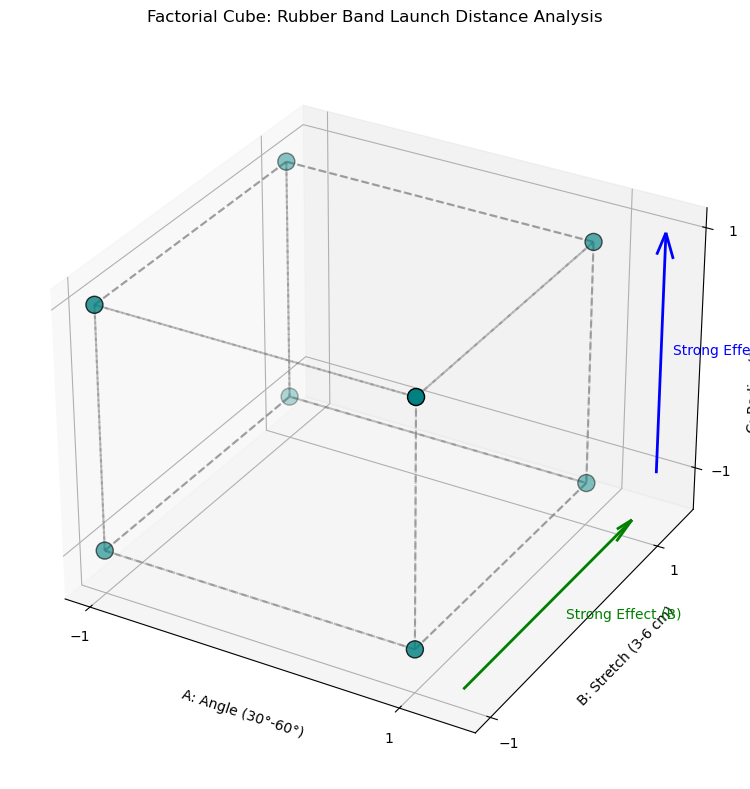

In [12]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Group by your factors and calculate the mean Distance at each corner
cube_df = df.groupby(["A", "B", "C"], as_index=False)["Distance"].mean()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 2. Plot the corner points
ax.scatter(cube_df["A"], cube_df["B"], cube_df["C"], s=150, color='teal', edgecolors='black')

# 3. Label each corner with the mean distance
for _, row in cube_df.iterrows():
    ax.text(row["A"], row["B"], row["C"] + 15, 
            f'{row["Distance"]:.1f}', 
            fontsize=10, fontweight='bold', ha='center')

# 4. Define cube edges
corners = [
    (-1,-1,-1), (1,-1,-1), (-1,1,-1), (1,1,-1),
    (-1,-1,1), (1,-1,1), (-1,1,1), (1,1,1)
]

for c1 in corners:
    for c2 in corners:
        diff = sum(abs(a-b) for a,b in zip(c1, c2))
        if diff == 2:
            ax.plot([c1[0], c2[0]], [c1[1], c2[1]], [c1[2], c2[2]], 
                    color="gray", linestyle="--", alpha=0.5)

# 5. Updated labels based on your factor assignments
ax.set_xlabel("A: Angle (30°-60°)")
ax.set_ylabel("B: Stretch (3-6 cm)")
ax.set_zlabel("C: Radius (1.5-3.5 cm)")

# 6. Highlighting the Strongest Effects from your ANOVA results
# Factor C (Radius) - Vertical Axis (Highest F-stat in your data)
ax.quiver(1.3, 1.3, -1, 0, 0, 2, color="blue", linewidth=2, arrow_length_ratio=0.1)
ax.text(1.35, 1.35, 0, "Strong Effect (C)", color="blue", rotation=90)

# Factor B (Stretch) - Y Axis (Second highest F-stat)
ax.quiver(1.3, -1, -1.2, 0, 2, 0, color="green", linewidth=2, arrow_length_ratio=0.1)
ax.text(1.4, 0, -1.3, "Strong Effect (B)", color="green")

ax.set_xticks([-1, 1])
ax.set_yticks([-1, 1])
ax.set_zticks([-1, 1])

ax.set_title("Factorial Cube: Rubber Band Launch Distance Analysis", pad=20)
plt.tight_layout()

plt.show()

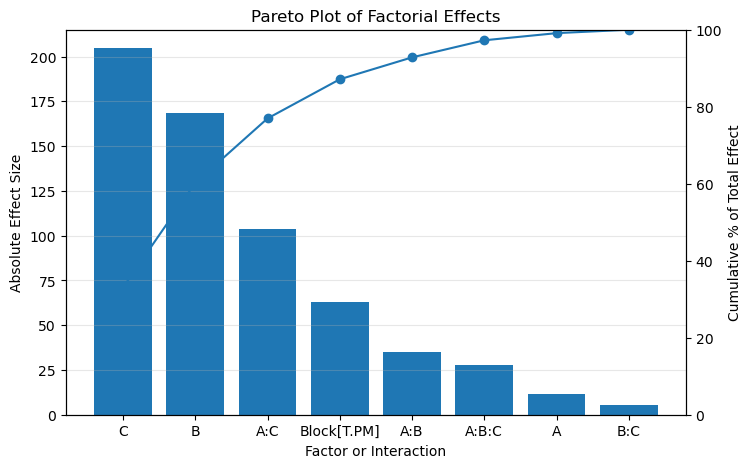

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract coefficients
coef = results.params.drop("Intercept")

# Convert regression coefficients to factorial effects
effects = 2 * coef

pareto_df = pd.DataFrame({
    "Term": effects.index,
    "Effect": effects.values
})

pareto_df["AbsEffect"] = pareto_df["Effect"].abs()

# Sort largest → smallest for Pareto
pareto_df = pareto_df.sort_values("AbsEffect", ascending=False)

# Compute cumulative percentage
pareto_df["CumPercent"] = pareto_df["AbsEffect"].cumsum() / pareto_df["AbsEffect"].sum() * 100

# Plot
fig, ax1 = plt.subplots(figsize=(8,5))

# Bar plot
ax1.bar(pareto_df["Term"], pareto_df["AbsEffect"])
ax1.set_ylabel("Absolute Effect Size")
ax1.set_xlabel("Factor or Interaction")
ax1.set_title("Pareto Plot of Factorial Effects")
ax1.grid(axis="y", alpha=0.3)

# Second axis for cumulative line
ax2 = ax1.twinx()
ax2.plot(pareto_df["Term"], pareto_df["CumPercent"], marker="o")
ax2.set_ylabel("Cumulative % of Total Effect")
ax2.set_ylim(0,100)

plt.show()

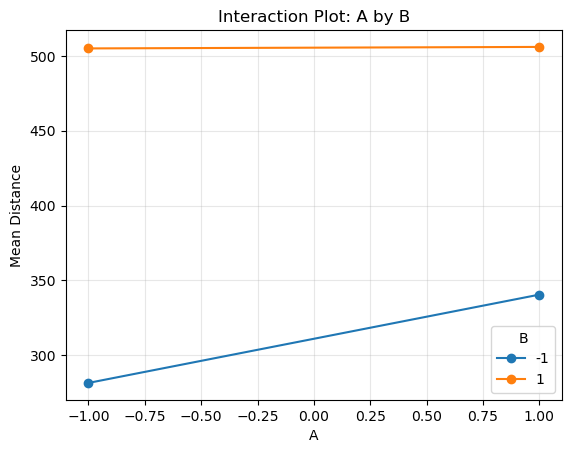

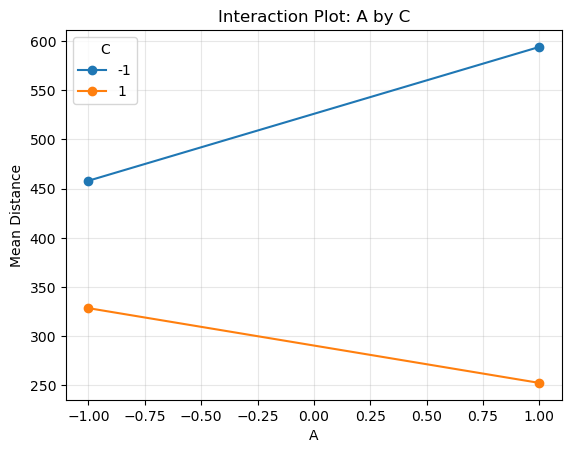

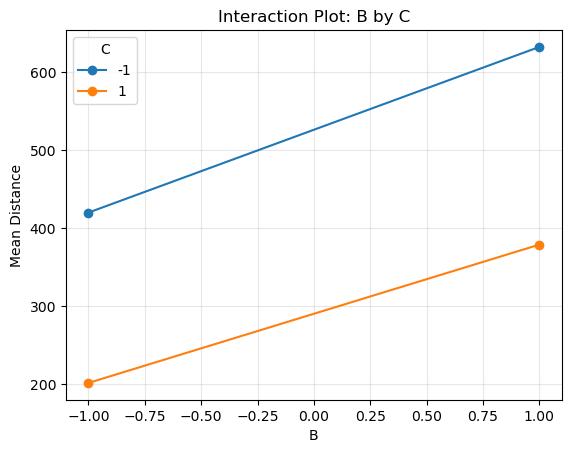

In [14]:
def interaction_plot(df, x, trace, response="Distance"):
    means = df.groupby([x, trace])[response].mean().unstack()
    means.plot(marker="o")
    plt.xlabel(x)
    plt.ylabel(f"Mean {response}")
    plt.title(f"Interaction Plot: {x} by {trace}")
    plt.grid(alpha=0.3)
    plt.show()

interaction_plot(dfa, "A", "B")
interaction_plot(dfa, "A", "C")
interaction_plot(dfa, "B", "C")

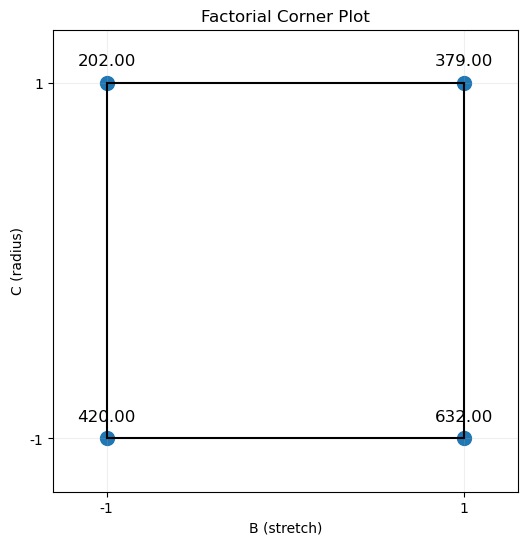

In [17]:
import matplotlib.pyplot as plt

# Compute means
pivot = dfa.pivot_table(values="Distance", index="C", columns="B", aggfunc="mean")

plt.figure(figsize=(6,6))

# Draw square boundary
plt.plot([-1, 1], [-1, -1], 'k-')
plt.plot([-1, 1], [ 1,  1], 'k-')
plt.plot([-1, -1], [-1, 1], 'k-')
plt.plot([ 1,  1], [-1, 1], 'k-')

# Draw corner points
plt.scatter([-1, 1, -1, 1], [-1, -1, 1, 1], s=100)

# Put the mean responses at the corners
corner_values = {
    (-1, -1): pivot.loc[-1, -1],
    ( 1, -1): pivot.loc[-1,  1],
    (-1,  1): pivot.loc[ 1, -1],
    ( 1,  1): pivot.loc[ 1,  1]
}

for (b, c), val in corner_values.items():
    plt.text(b, c + 0.08, f"{val:.2f}", ha="center", va="bottom", fontsize=12)

# Axis labels and formatting
plt.xlim(-1.3, 1.3)
plt.ylim(-1.3, 1.3)
plt.xticks([-1, 1], [-1, 1])
plt.yticks([-1, 1], [-1, 1])

plt.xlabel("B (stretch)")
plt.ylabel("C (radius)")
plt.title("Factorial Corner Plot")

plt.grid(alpha=0.2)
plt.show()

In [19]:
reduced_model = ols("Distance ~ B * C", data=dfa)
reduced_results=reduced_model.fit()
print(reduced_results.summary())


                            OLS Regression Results                            
Dep. Variable:               Distance   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.771
Method:                 Least Squares   F-statistic:                     8.872
Date:                Tue, 14 Apr 2026   Prob (F-statistic):             0.0306
Time:                        14:04:21   Log-Likelihood:                -44.012
No. Observations:                   8   AIC:                             96.02
Df Residuals:                       4   BIC:                             96.34
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    408.2500     29.650     13.769      0.0

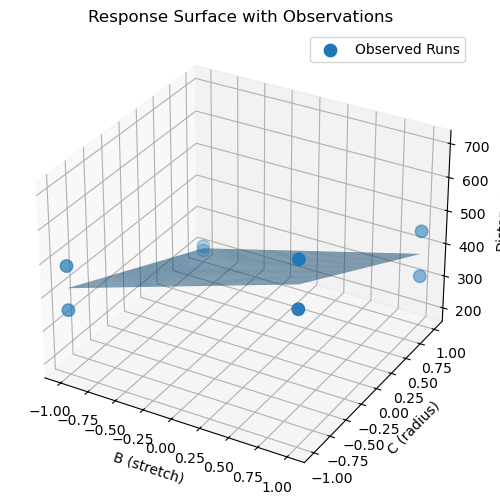

In [20]:
# Response Surface
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create grid
B_vals = np.linspace(-1, 1, 40)
C_vals = np.linspace(-1, 1, 40)
B_grid, C_grid = np.meshgrid(B_vals, C_vals)

# Put grid into dataframe for prediction
grid_df = pd.DataFrame({
    "B": B_grid.ravel(),
    "C": C_grid.ravel()
})

# Predict from fitted model
grid_df["Predicted_Distance"] = reduced_results.predict(grid_df)

# Reshape predictions back to grid
Z = grid_df["Predicted_Distance"].values.reshape(B_grid.shape)

# Plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")

# Surface
ax.plot_surface(B_grid, C_grid, Z, alpha=0.6)

# Observed data points
ax.scatter(
    dfa["B"],
    dfa["C"],
    dfa["Distance"],
    s=80,
    marker="o",
    label="Observed Runs"
)

ax.set_xlabel("B (stretch)")
ax.set_ylabel("C (radius)")
ax.set_zlabel("Distance")
ax.set_title("Response Surface with Observations")

ax.legend()

plt.show()

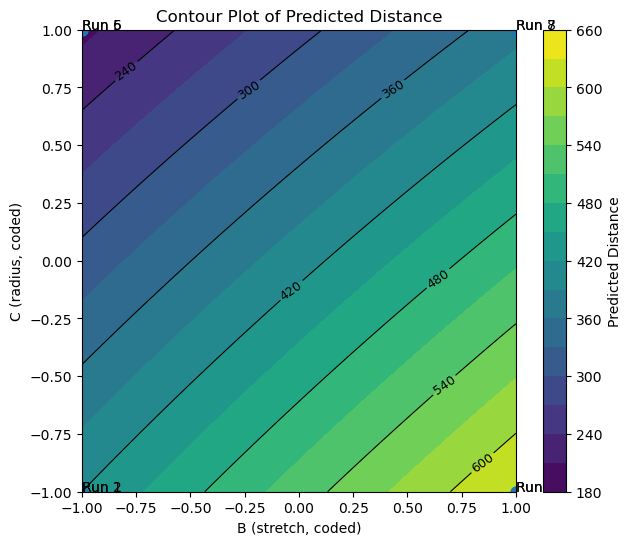

In [21]:
# Contour Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

# Filled contours
cp = plt.contourf(B_vals, C_vals, Z, levels=15)

# Contour lines
cs = plt.contour(B_vals, C_vals, Z, colors="black", linewidths=0.8)
plt.clabel(cs, inline=True, fontsize=9)

# Observed design points
plt.scatter(design["B"], design["C"], s=60)

# Label run numbers
for _, row in design.iterrows():
    plt.text(row["B"], row["C"], f'Run {row["Run"]}', fontsize=10)

plt.xlabel("B (stretch, coded)")
plt.ylabel("C (radius, coded)")
plt.title("Contour Plot of Predicted Distance")

plt.colorbar(cp, label="Predicted Distance")

plt.show()